<a href="https://colab.research.google.com/github/R4Z47/covid19-county-analysis/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATH 3332 - Data Science and Applied Machine Learning
Project 1 - COVID-19 Community Levels by County

Research Focus: County-Level Comparisons

Date of Submission - March 9, 2026

Group Name - Anurag Jung Basnet, Razat Sangraula, Surendra Thapa

This project focuses on comparing COVID-19 Community Levels across U.S. counties from February to October 2022. We analyzed how counties differed in case rates, hospital admissions, and community risk levels. Our goal was to identify which counties and states were hit hardest and how those levels changed over time

In [ ]:
# Importing the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
# This line just silences minor warning messages so our output stays clean
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams.update({
'figure.facecolor': 'white',
'axes.facecolor':   '#f9f9f9',
'axes.grid':        True,
'grid.alpha':       0.4,
'font.size':        11,
})

In [ ]:
#LOAD DATA
#Reading the csv file from our colab files
df_raw = pd.read_csv('/content/United_States_COVID-19_Community_Levels_by_County.csv')
print(f"Rows: {df_raw.shape[0]:,}  Columns: {df_raw.shape[1]}")
print(df_raw.columns.tolist())
df_raw.head(2)

Rows: 112,836  Columns: 12
['county', 'county_fips', 'state', 'county_population', 'health_service_area_number', 'health_service_area', 'health_service_area_population', 'covid_inpatient_bed_utilization', 'covid_hospital_admissions_per_100k', 'covid_cases_per_100k', 'covid-19_community_level', 'date_updated']


,county,county_fips,state,county_population,health_service_area_number,health_service_area,health_service_area_population,covid_inpatient_bed_utilization,covid_hospital_admissions_per_100k,covid_cases_per_100k,covid-19_community_level,date_updated
0,Lincoln County,55069,Wisconsin,27593.0,282,"Marathon (Wausau), WI - Wood, WI",291401.0,4.7,13.4,177.58,Medium,2022-08-18
1,Manitowoc County,55071,Wisconsin,78981.0,355,"Sheboygan (Sheboygan), WI - Manitowoc, WI",244410.0,3.4,9.8,169.66,Low,2022-08-18


In [ ]:
#DATA CLEANING
#Making a copy of the dataset so we don't mess up the original
df = df_raw.copy()

#Converting the date column from a string to an actual date
df['date_updated'] = pd.to_datetime(df['date_updated'], errors='coerce')

#Renaming this colunm
df.rename(columns={'covid-19_community_level': 'community_level'}, inplace=True)

#Dropping rows that are missing county, state, or case data
df.dropna(subset=['county', 'state', 'covid_cases_per_100k'], inplace=True)

#The community level column had mixed casing like 'low', 'Low', 'LOW'
#So we are standardizing everything to 'Low', 'Medium', 'High'
df['community_level'] = df['community_level'].str.strip().str.capitalize()
df.dropna(subset=['community_level'], inplace=True)
print(f"After cleaning: {len(df):,} rows")
print(f"Community levels: {df['community_level'].unique()}")

After cleaning: 112,782 rows
Community levels: ['Medium' 'Low' 'High']


In [ ]:
#Removing U.S. territories since we're focusing on mainland states
#Territories like Puerto Rico and Guam had much higher rates and would skew results
territories = ['American Samoa', 'Puerto Rico', 'Guam','Commonwealth of the Northern Mariana Islands', 'Virgin Islands']
df_mainland = df[~df['state'].isin(territories)].copy()
print(f"Mainland rows: {len(df_mainland):,}")

Mainland rows: 109,971


In [ ]:
#Stats on case rates
display(df_mainland['covid_cases_per_100k'].describe().round(2).to_frame())

#Average cases per state to find which states were hit hardest
state_avg = (df_mainland.groupby('state')['covid_cases_per_100k']
             .mean().sort_values(ascending=False))
display(state_avg.head(10).round(2).to_frame().rename(columns={'covid_cases_per_100k': 'avg_cases_per_100k'}))

,covid_cases_per_100k
count,109971.00
mean,137.27
std,173.36
min,0.00
25%,43.80
50%,104.78
75%,189.18
max,13017.75


,avg_cases_per_100k
state,
Alaska,312.16
Rhode Island,205.04
West Virginia,202.89
Vermont,195.71
New Jersey,191.15
Maine,188.11
Hawaii,179.71
Kentucky,178.55
Virginia,174.15


In [ ]:
#Getting the most recent record for each county
# this way we're looking at a snapshot instead of averaging everything
latest = (df_mainland.sort_values('date_updated')
          .groupby(['county', 'state'], as_index=False).last())

#Top 15 counties with the highest case rates
top15 = (latest.nlargest(15, 'covid_cases_per_100k')
         [['county', 'state', 'covid_cases_per_100k']]
         .reset_index(drop=True))
display(top15)

#Top 5 states we'll use for the line chart
top5_states = state_avg.head(5).index.tolist()

,county,state,covid_cases_per_100k
0,Hoonah-Angoon Census Area,Alaska,2327.75
1,Yakutat City and Borough,Alaska,2327.75
2,McPherson County,South Dakota,1681.38
3,Craig County,Virginia,1403.24
4,Loving County,Texas,1183.43
5,Floyd County,Virginia,1015.94
6,Bland County,Virginia,875.80
7,Wrangell City and Borough,Alaska,759.39
8,Douglas County,Kansas,680.52
9,Chattahoochee County,Georgia,577.61


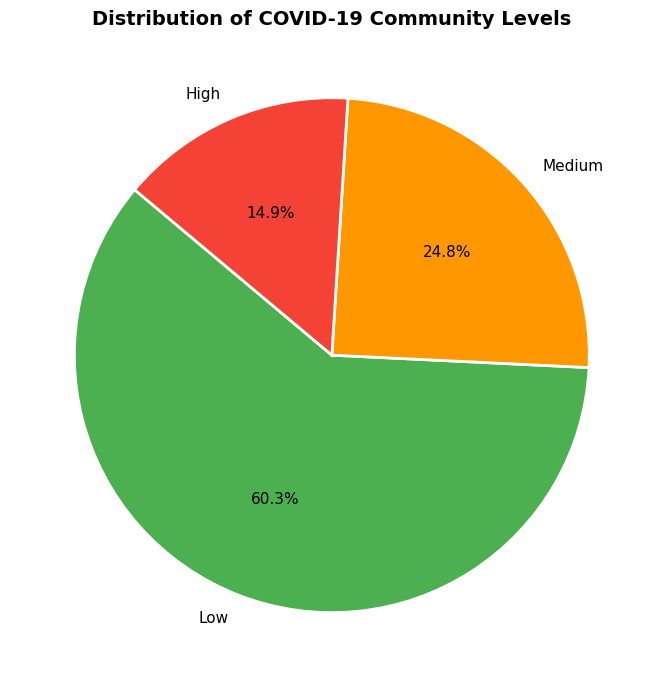

In [ ]:
#Making a PIE CHART
#Showing the breakdown of Low / Medium / High community levels
level_counts = df_mainland['community_level'].value_counts()
colors_pie = ['#4caf50', '#ff9800', '#f44336']  # green, orange, red
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(level_counts, labels=level_counts.index, autopct='%1.1f%%',startangle=140, colors=colors_pie,wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Distribution of COVID-19 Community Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_community_levels.png', dpi=150, bbox_inches='tight')
plt.show()

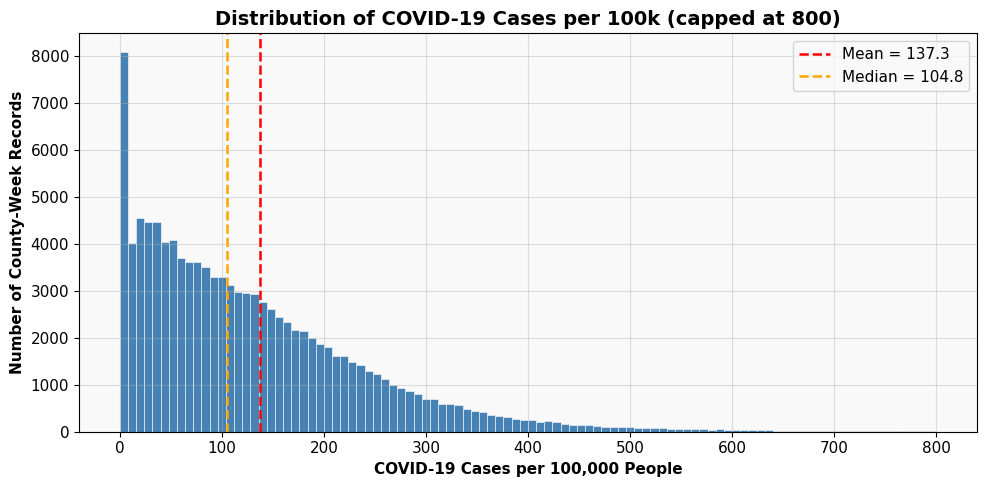

In [ ]:
#Making a HISTOGRAM
#Showing how cases per 100k are spread across all counties
#We're capping it to 800 because a few extreme outliers mgiht stretch the chart way out
fig, ax = plt.subplots(figsize=(10, 5))
data = df_mainland['covid_cases_per_100k'].dropna()
data_capped = data[data <= 800]
ax.hist(data_capped, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)

#Adding mean and median lines so we can see the skew
ax.axvline(data.mean(), color='red', linestyle='--', lw=1.8,label=f'Mean = {data.mean():.1f}')
ax.axvline(data.median(), color='orange', linestyle='--', lw=1.8,label=f'Median = {data.median():.1f}')
ax.set_xlabel('COVID-19 Cases per 100,000 People', fontweight='bold')
ax.set_ylabel('Number of County-Week Records', fontweight='bold')
ax.set_title('Distribution of COVID-19 Cases per 100k (capped at 800)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('histogram_cases.png', dpi=150, bbox_inches='tight')
plt.show()

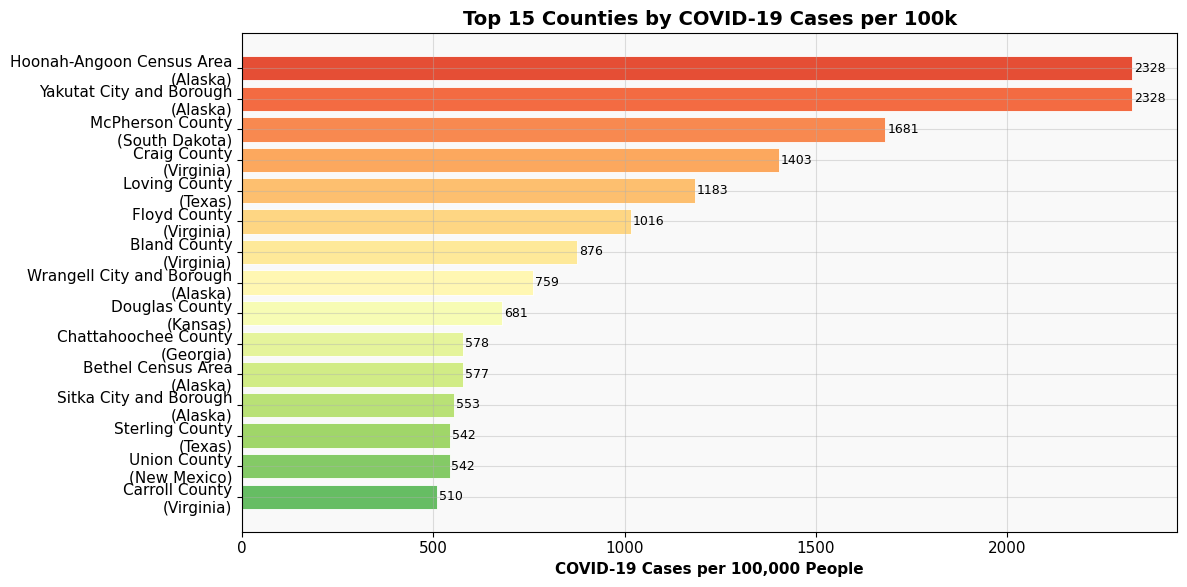

In [ ]:
#making a BAR CHART
#Top 15 counties ranked by their most recent case rate
fig, ax = plt.subplots(figsize=(12, 6))
labels = top15['county'] + '\n(' + top15['state'] + ')'
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, 15))  # red to green color scale
ax.barh(labels[::-1], top15['covid_cases_per_100k'][::-1],color=colors, edgecolor='white', linewidth=0.6)
ax.set_xlabel('COVID-19 Cases per 100,000 People', fontweight='bold')
ax.set_title('Top 15 Counties by COVID-19 Cases per 100k', fontsize=14, fontweight='bold')

#Adding the actual numbers at the end of each bar
for i, v in enumerate(top15['covid_cases_per_100k'][::-1]):
 ax.text(v + 5, i, f'{v:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('bar_top15_counties.png', dpi=150, bbox_inches='tight')
plt.show()

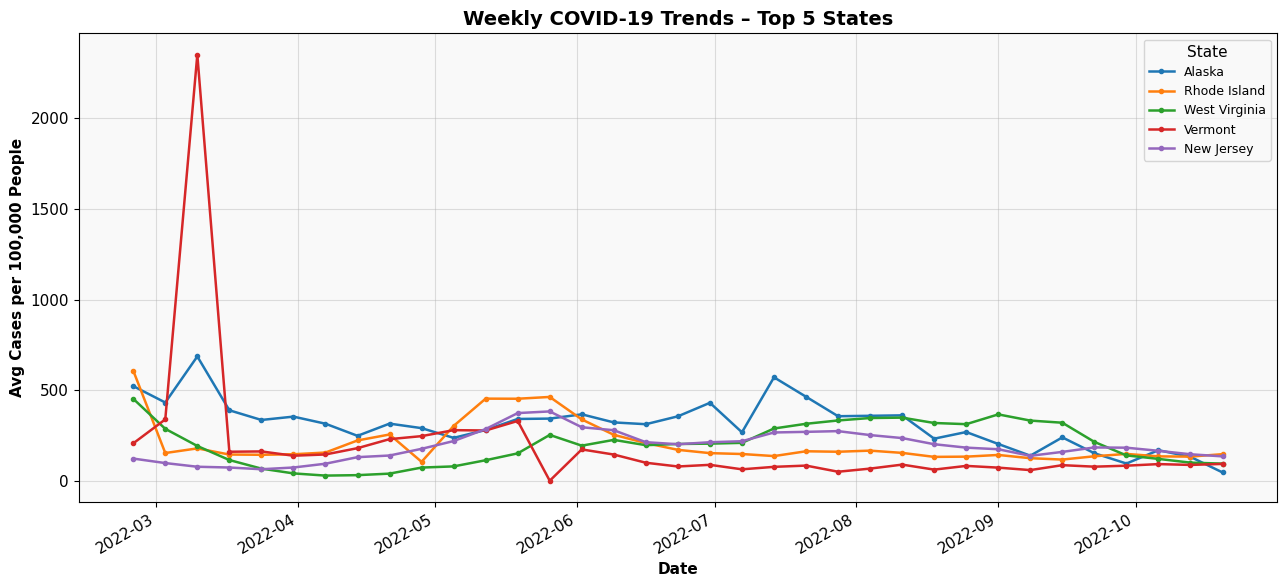

In [ ]:
#making a LINE CHART
#tracking how cases changed week by week for the top 5 states
weekly = (df_mainland[df_mainland['state'].isin(top5_states)].groupby(['state', 'date_updated'])['covid_cases_per_100k'].mean().reset_index())
fig, ax = plt.subplots(figsize=(13, 6))
for state in top5_states:
    ts = weekly[weekly['state'] == state].sort_values('date_updated')
    ax.plot(ts['date_updated'], ts['covid_cases_per_100k'],
            marker='o', markersize=3, linewidth=1.8, label=state)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Avg Cases per 100,000 People', fontweight='bold')
ax.set_title('Weekly COVID-19 Trends – Top 5 States', fontsize=14, fontweight='bold')
ax.legend(title='State', fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('line_state_trends.png', dpi=150, bbox_inches='tight')
plt.show()